# Notebook 4 - Otimização de Modelo

Importando bibliotecas:

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, roc_auc_score, fbeta_score, roc_curve, precision_recall_curve

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

## Carregando dados e preparar

In [31]:
data = pd.read_parquet('../data/features/dados_modelo.parquet')
data.head()

,inadimplente,log_renda_mensal,tem_atraso_grave,total_atrasos,idade,uso_credito_rotativo,razao_divida_renda,razao_extrema,num_dependentes,linhas_credito_abertas,emprestimos_imobiliarios
0,1,9.118335,0,2,45,0.766127,0.802982,0,2.0,13,6
1,0,7.863651,0,0,40,0.957151,0.121876,0,1.0,4,0
2,0,8.020599,1,2,38,0.658180,0.085113,0,0.0,2,0
3,0,8.101981,0,0,30,0.233810,0.036050,0,0.0,5,0
4,0,11.060196,0,1,49,0.907239,0.024926,0,0.0,7,1


In [32]:
X = data.drop(columns=['inadimplente'])
y = data['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Pré-processamento:

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

## Definindo espaço de busca

In [34]:
params_distributions = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

In [35]:
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params_distributions,
    scoring='f1',
    cv=cv,
    n_iter=50,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

search.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   4.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [36]:
print(search.best_params_)
print(f"\nMelhor F1-Score no CV: {search.best_score_:.4f}")

{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Melhor F1-Score no CV: 0.9539


In [37]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print("Performance no conjunto de TESTE:")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

Performance no conjunto de TESTE:
F1-Score:  0.3485
Precision: 0.4543
Recall:    0.2827
AUC-ROC:   0.8317


## Reduzindo Overfitting

In [38]:
params_distributions_v2 = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [200, 300, 400],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5]
}

In [39]:
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params_distributions_v2,
    scoring='f1',
    cv=cv,
    n_iter=100,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

search.fit(X_train_res, y_train_res)

print(search.best_params_)
print(f"\nMelhor F1-Score no CV: {search.best_score_:.4f}")

best_model = search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print("Performance no conjunto de TESTE:")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimators=400, reg_alpha=0.5, reg_l

## Ajuste de Threshold

In [40]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print("Threshold | F2-Score | Recall | Precision")
print("-" * 45)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    print(f"   {thresh:.1f}    |  {f2:.4f}  | {rec:.4f} |  {prec:.4f}")

Threshold | F2-Score | Recall | Precision
---------------------------------------------
   0.2    |  0.4988  | 0.7458 |  0.2146
   0.2    |  0.5143  | 0.6933 |  0.2530
   0.3    |  0.5095  | 0.6324 |  0.2867
   0.3    |  0.4966  | 0.5744 |  0.3221
   0.4    |  0.4798  | 0.5260 |  0.3551
   0.5    |  0.4579  | 0.4795 |  0.3879
   0.5    |  0.4283  | 0.4306 |  0.4195
   0.6    |  0.3904  | 0.3776 |  0.4516
   0.6    |  0.3389  | 0.3162 |  0.4759


## Regressão Logística

In [47]:
params_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

lr = LogisticRegression(random_state=42)
search_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions = params_lr,
    scoring='f1',
    cv=cv,
    n_iter=50,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

search_lr.fit(X_train_res, y_train_res)

print(search_lr.best_params_)
print(f"\nMelhor F1-Score no CV: {search_lr.best_score_:.4f}")
best_lr = search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("\nPerformance no conjunto de TESTE:")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=balanced, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=balanced, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=balanced, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=balanced, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l2; total time=   0.2s
[CV] END C=0.001, class_weight=balanced, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1; total time=   0.0s
[CV] 

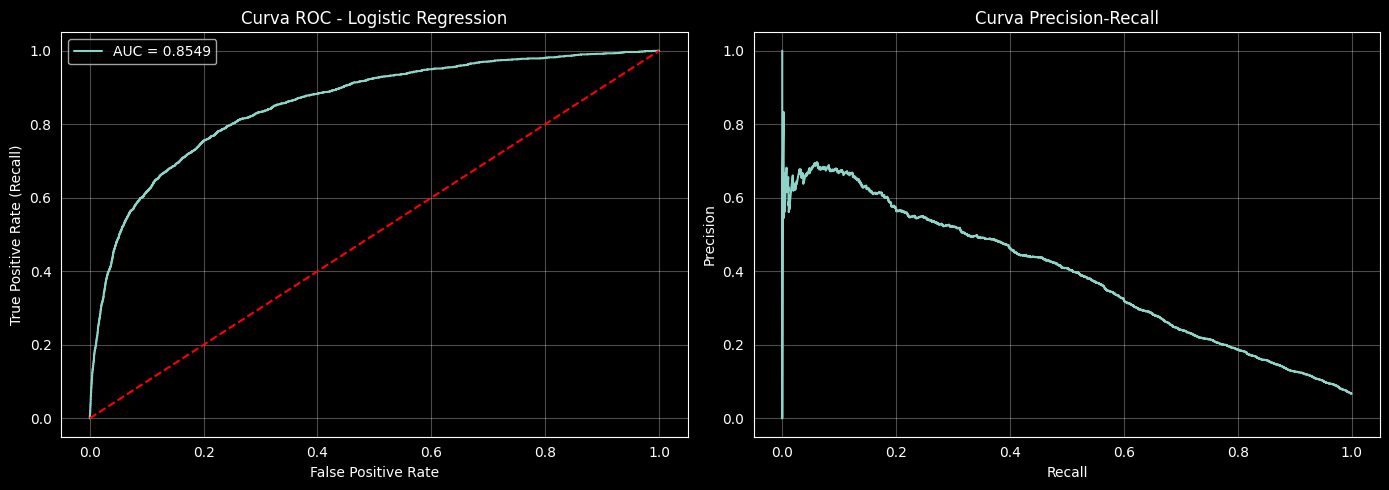

Coeficientes do modelo (ordenados por importância):
                    feature  coeficiente
2             total_atrasos     0.880209
4      uso_credito_rotativo     0.716424
3                     idade    -0.322782
1          tem_atraso_grave     0.222572
8    linhas_credito_abertas     0.159875
5        razao_divida_renda     0.139505
6             razao_extrema    -0.098465
9  emprestimos_imobiliarios     0.076428
0          log_renda_mensal    -0.010892
7           num_dependentes    -0.002481


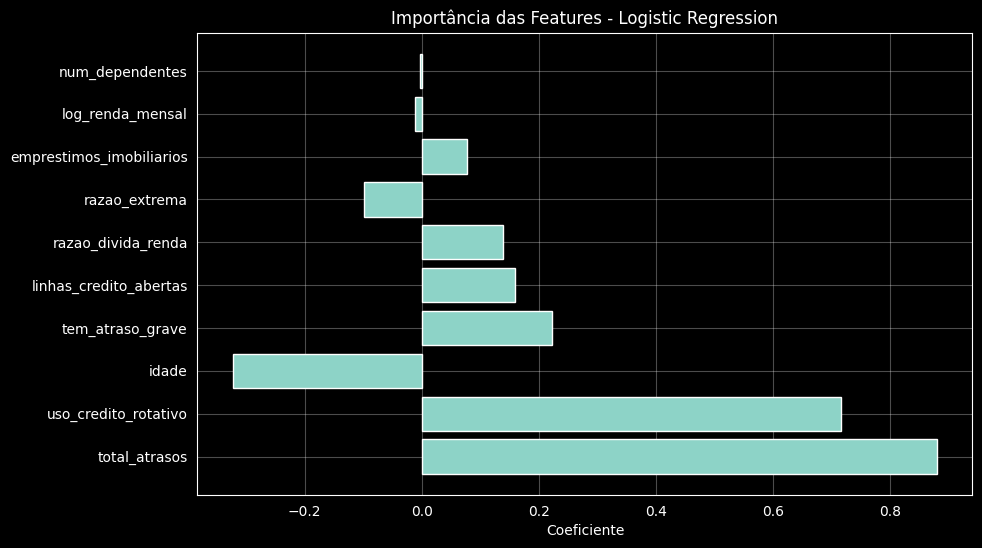

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob_lr):.4f}')
axes[0].plot([0, 1], [0, 1], 'r--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Curva ROC - Logistic Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

  # Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob_lr)
axes[1].plot(rec, prec)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

coefs = pd.DataFrame({
      'feature': X.columns,
      'coeficiente': best_lr.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print("Coeficientes do modelo (ordenados por importância):")
print(coefs)

  # Plot
plt.figure(figsize=(10, 6))
plt.barh(coefs['feature'], coefs['coeficiente'])
plt.xlabel('Coeficiente')
plt.title('Importância das Features - Logistic Regression')
plt.grid(True, alpha=0.3)
plt.show()

## Salvando Modelo Final

In [52]:
import joblib

joblib.dump(best_lr, '../src/models/logistic_regression_final.joblib')
joblib.dump(scaler, '../src/models/scaler.joblib')
joblib.dump(X.columns.tolist(), '../src/models/feature_names.joblib')
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


## Resumo do Notebook 4 - Otimização de Modelo

### Objetivo
Otimizar hiperparâmetros dos modelos e selecionar o melhor modelo final para produção.

### Técnica de Otimização
- **RandomizedSearchCV**: Busca aleatória de hiperparâmetros
- **Validação Cruzada**: StratifiedKFold com 5 folds
- **Métrica de Otimização**: F1-Score

### Modelos Otimizados

#### 1. XGBoost (primeira versão)
**Espaço de busca:**
- `max_depth`: [3, 5, 7, 9]
- `learning_rate`: [0.01, 0.05, 0.1, 0.2]
- `n_estimators`: [100, 200, 300]
- `min_child_weight`: [1, 3, 5]
- `subsample`: [0.7, 0.8, 0.9]
- `colsample_bytree`: [0.7, 0.8, 0.9]

**Problema identificado:** Overfitting severo (F1 CV: 0.95 vs F1 teste: 0.35)

#### 2. XGBoost (com regularização)
**Ajustes no espaço de busca:**
- `max_depth`: [3, 4, 5, 6] (reduzido)
- `learning_rate`: [0.01, 0.03, 0.05] (reduzido)
- `reg_alpha`: [0, 0.1, 0.5, 1] (adicionado)
- `reg_lambda`: [1, 2, 5] (adicionado)

**Resultado:** Overfitting reduzido, mas ainda presente

#### 3. Logistic Regression
**Espaço de busca:**
- `C`: [0.001, 0.01, 0.1, 1, 10, 100]
- `penalty`: ['l1', 'l2']
- `class_weight`: [None, 'balanced']

**Melhores hiperparâmetros:** `{'penalty': 'l2', 'C': 0.1, 'class_weight': None}`

### Comparação Final dos Modelos Otimizados

| Modelo | F1 (CV) | F1 (teste) | Precision | Recall | AUC-ROC | Gap |
|--------|---------|------------|-----------|--------|---------|-----|
| XGBoost (reg.) | 0.9312 | 0.4249 | 0.4195 | 0.4306 | 0.8536 | 0.51 |
| **Logistic Regression** | 0.7663 | 0.3345 | 0.2154 | **0.7483** | **0.8549** | **0.43** |

### Modelo Escolhido: Logistic Regression

**Justificativa:**
- **Menor overfitting** (gap de 0.43 vs 0.51)
- **Recall alto** (74.8% dos inadimplentes detectados)
- **AUC-ROC superior** (0.8549)
- **Regra de negócio**: Em risco de crédito, é preferível recusar bons clientes (falso positivo) do que aprovar maus pagadores (falso negativo)

### Análise de Threshold (XGBoost)
- Threshold 0.25: Recall 0.69, Precision 0.25, F2 0.51
- Threshold 0.50: Recall 0.43, Precision 0.42, F2 0.43

### Features Mais Importantes (Logistic Regression)
Os coeficientes do modelo indicam quais features têm maior peso na decisão de classificação.

### Artefatos Salvos
- `logistic_regression_final.joblib`: Modelo otimizado final
- `scaler.joblib`: StandardScaler treinado
- `feature_names.joblib`: Lista de features

### Métricas Finais do Modelo em Produção
- **AUC-ROC**: 0.8549
- **Recall**: 0.7483 (detecta ~75% dos inadimplentes)
- **Precision**: 0.2154
- **F1-Score**: 0.3345

### Limitações Identificadas
- F1-Score abaixo da meta inicial (0.80)
- Precision baixa gera muitos falsos positivos
- Desbalanceamento extremo do dataset limita a performance

### Próximos Passos
- Criar pipeline de treinamento reutilizável (`src/models/train.py`)
- Implementar funções de avaliação (`src/models/evaluate.py`)
- Criar módulo de predição (`src/models/predict.py`)